# Python Course: Final Assignment
# Part 1: Regression Analysis
# Data Subject : Regression - House Price Prediction
# Author Stavros Stavropoulos

In [1]:
import pandas as pd # Don't forget to select the appropriate Kernel at the top right
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Setting to make all the charts look nice
%matplotlib inline
sns.set(style="whitegrid")

try:
    print("Libraries imported successfully!Yeah!!!") # Just a message to confirm that the libraries have been imported without any issues.
except ImportError as e:
    print("❌ Welp, it appears that we have a problem.")
    print("Try and check if the libraries have been downloaded or redownload them again correctly.")
    print(f"The libraries are: pandas, numpy, matplotlib, seaborn.")
    print(f"Specific error: {e}")   # This will print the specific error message if only one is missing (e.g., only seaborn), Python will tell you specifically there, so you will save time. ;)
    

Libraries imported successfully!Yeah!!!


Step 1

In [2]:
# For starters, let's load the dataset
base_path = Path('.').resolve()
train_path = base_path / 'data' / 'train.csv'
 
try:
    df = pd.read_csv(train_path,sep=';') # WARNING: The file name MUST be in quotation marks ' '.
    # Also we use sep=';' because the data in the CSV is separated by a semicolon instead of a comma. If we don't do this, pandas will read the entire line as a single column.
    print(f"✅ Dataset loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    print("❌ Error: 'train.csv' not found. Please check the file path.")

✅ Dataset loaded successfully! Shape: (1460, 81)


Step 2

In [3]:
# Now for step 2, let's take a look at the fisrt few rows of the dataset as an Exploratory Data Analysis. 
# This way we will understand our datasets structure, the types of variables it contains, and the distribution of our target variable 'SalePrice'.
print("\n--- First 5 rows of the dataset ---")
display(df.head())  # I use .head() to show the first 5 rows of the dataset to ensure the data was loaded correctly.

print("\n--- Summary Information ---") 
df.info() # We use .info() to indentify the data types of each column and check for any missing values

print("\n--- Descriptive Statistics for Target Variable (SalePrice) ---")
display(df['SalePrice'].describe()) # Descriptive statistics help us understand the range, mean, and potential outliers in house prices.



--- First 5 rows of the dataset ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Summary Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Step 3


⚠️ Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


C:\Users\Σταυρος\AppData\Local\Temp\ipykernel_27524\3629872547.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette="Reds_r") # This one creates a bar plot with x-axis and y-axis values from the missing variable. The palette Reds_r makes the bars red color.


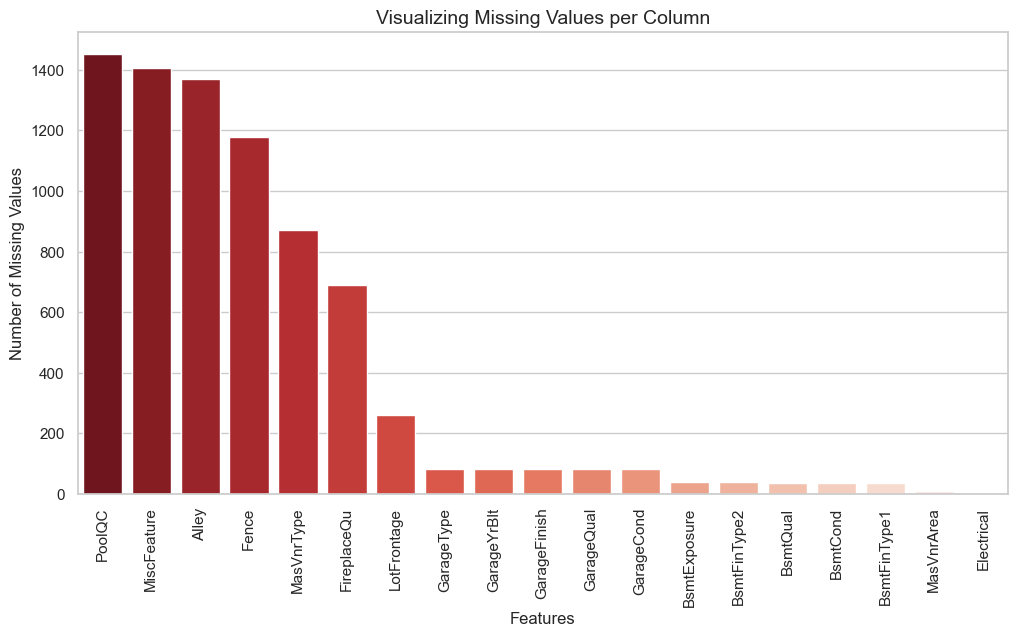

In [4]:
# Now for step 3, let's check for missing values in the dataset. This will help us understand if we need to perform any data modifications or imputations before we can proceed with modeling.
missing = df.isnull().sum() # Calculate the sum of null values for every column in the dataset.
missing = missing[missing > 0].sort_values(ascending=False) # This helps us to filter out columns that have 0 missing values and sort them. So that we can focus on the on the most ptoblematic features first.

if not missing.empty:
    print("\n⚠️ Columns with missing values:")
    print(missing)
else:
    print("\n✅ No missing values found!")
    # This was done so that we can perform a validation check to inform the user about the data quality.
    # If the data was clean, we can proceed directly to modeling without worrying about future issues that may arise from missing data.
# If there are any missing values, let's visualize them so that we can undertsnand better which features are affected the most and how to deal with them.
plt.figure(figsize=(12, 6)) # This sets the size of the plot to make it more readable, especilly if there are many features with missing values.
sns.barplot(x=missing.index, y=missing.values, palette="Reds_r") # This one creates a bar plot with x-axis and y-axis values from the missing variable. The palette Reds_r makes the bars red color.


plt.xticks(rotation=90) # This rotates the axis labels by 90 degrees to prevent overlapping and improve readability.
plt.xlabel("Features", fontsize=12) # This sets the font size of the x-axis lavel.
plt.ylabel("Number of Missing Values", fontsize=12) # While this one sets for the y-axis label.
plt.title("Visualizing Missing Values per Column", fontsize=14) # This sets the title of the plot and increases the font size for better visibility.

plt.show() # This line is used to display the plot so it can be seen in the output of the notebook.

Step 4

In [5]:
# Now to step 4, let's data clean and preprocess the data. This is a detrimental step for the performance of our model. 
# We will handle missing values and drop collumns that have too many missing values (more than 40% missing values) to ensure that our model is trained on hight quality data.
# While the collums that have less than 40% missing values, we will try to fill them up where we can logically estimate their values.
threshold = 0.4
cols_to_drop = df.columns[df.isnull().mean() > threshold].tolist()
df_cleaned = df.drop(columns=cols_to_drop) #Dynamic deletion of columns based on the threshold you set
print(f" Automated Drop: Removed {len(cols_to_drop)} columns: {cols_to_drop}")
print(f" New shape: {df_cleaned.shape}")  # This will show us how many columns were dropped and the new form of the dataset.
# Now for the remaining columns with missing values,we will fill them up with the logical values.
# For starters we separate the remaining columns with blanks into numerical and categorical
numeric_cols_with_nan = df_cleaned.select_dtypes(include=[np.number]).columns[df_cleaned.select_dtypes(include=[np.number]).isnull().any()].tolist()
categorical_cols_with_nan = df_cleaned.select_dtypes(include=['object']).columns[df_cleaned.select_dtypes(include=['object']).isnull().any()].tolist()

for col in numeric_cols_with_nan:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median()) # Now we are filling the missing values in the numerical columns with the median value of each column.
    # The median is a good choice for filling missing values in numerical data because it is less affected by outliers compared to the mean.
    
for col in categorical_cols_with_nan:
    df_cleaned[col] = df_cleaned[col].fillna('None') # Now we are filling the missing values in the categorical columns with None. 
    # This is a common practice for categorical data, as it allows us to keep the missing values as a separate category without introducing problematic assumptions about what the missing values might be.
remaining_nans = df_cleaned.isnull().sum().sum() # This ensures that we have successfully filled all the missing values and there are no remainning Nans in the cleaned dataset.
print(f" Automated Imputation finished.") # Just a message to confirm that the imputation process was a sucess.
print(f"Filled {len(numeric_cols_with_nan)} numerical columns and {len(categorical_cols_with_nan)} categorical columns.") # This does a summary of how many columns were filled for each type, so we can have a better idea of the data cleaning process.
print(f" Total missing values remaining in df_cleaned: {remaining_nans}") # This should be 0 if all missing values were cleanned successfully.
# If not, it will show us how many missing values are still there.

 Automated Drop: Removed 6 columns: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
 New shape: (1460, 75)
 Automated Imputation finished.
Filled 3 numerical columns and 10 categorical columns.
 Total missing values remaining in df_cleaned: 0


Step 5

Top 10 features most positively correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


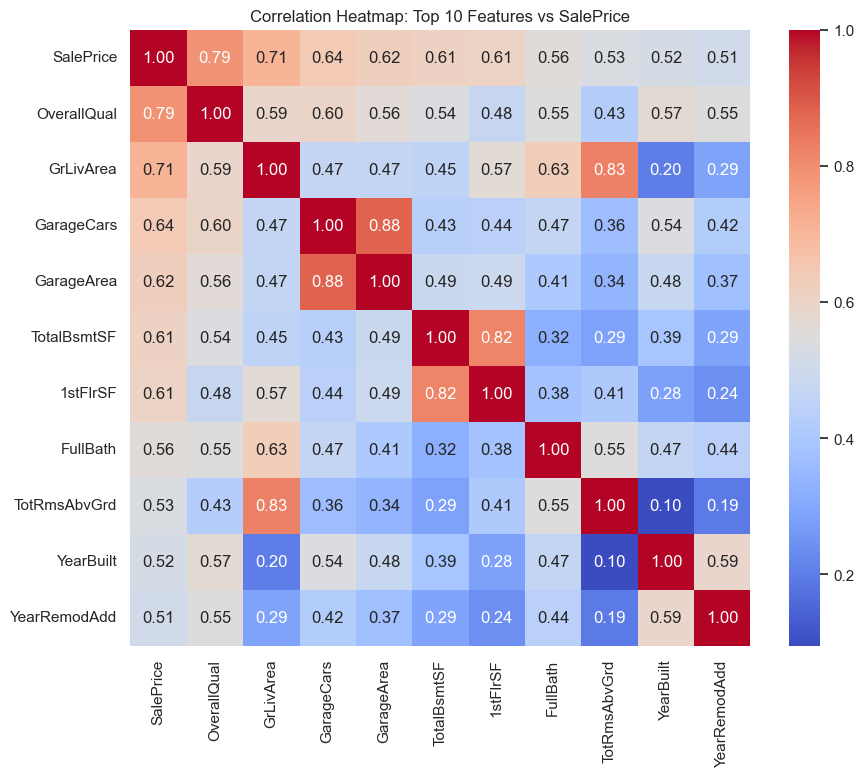

In [6]:
# Now for step 5, now that the dataset is clean we can now indentify the most impactful featues for predicting the target variable  'SalePrice'.
# This will help us make the regression model more efficient ,accurate and avoid noise from irrelevant features.
numeric_df = df_cleaned.select_dtypes(include=[np.number])  # This line selects only the numerical columns from the cleaned dataset beacuse correlation analysis requires numerical data.
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)  # This calculates the correlation of all the numerical data with the targeted variable 'SalePrice' and sorts them in descending order to easily indentify the most impactful features.
print("Top 10 features most positively correlated with SalePrice:")  # Just a message that says the output .
print(correlations.head(11))  # This will show us the top 10 features that have the highest positive correlation with our target variable . We uses head(11) beacause the first one will be the actual SalePrice itself that has a correlation of 1 ,so we want to skip that one and show the next 10.
top_features = correlations.index[:11]  # Selecting indices of the most impactful features for visualization.
plt.figure(figsize=(10, 8))  # Using coolwarm palette as our proffesor showed us to clearly distinguish between positive and negative correlations. 
sns.heatmap(df_cleaned[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")  # This line creates a heatmap to visualize the correlation.
plt.title("Correlation Heatmap: Top 10 Features vs SalePrice") 
plt.show()


Step 6

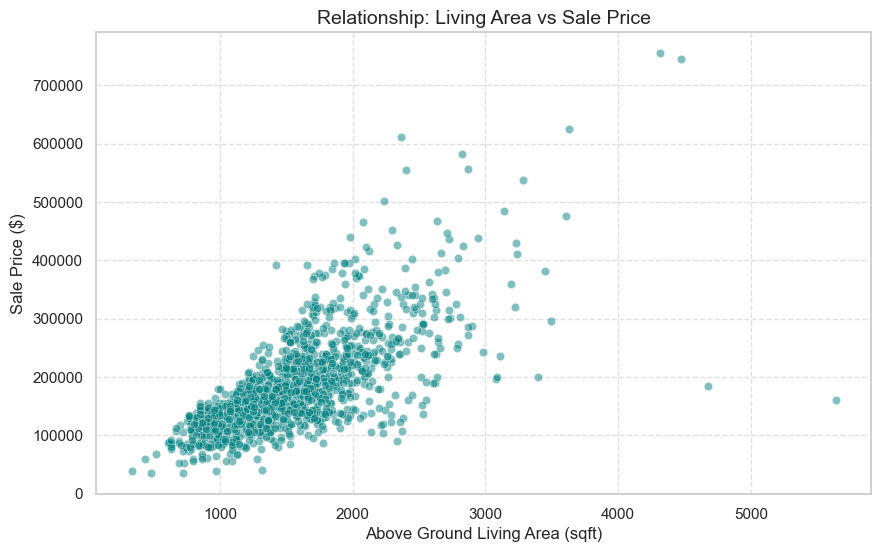

In [7]:
# Now for step 6, let's visually inspect the relatioships using scatter plots.
# Identifying and handling outliers is a critical part of the **Data Preprocessing** stage to ensure our Linear Regression model remains stable and accuret.
# We will use a scatter plot to see if there are any houses that deviate significantly from the general trend.
plt.figure(figsize=(10, 6)) # This sets the size of the plot.
sns.scatterplot(data=df_cleaned, x='GrLivArea', y='SalePrice', alpha=0.5, color='teal') # This creates a scatter plot. The alpha parameter is set to 0.5 to make the points semi-transparent, so it can help visualize areas with high density of points and identify potential outliers more easily.
plt.title('Relationship: Living Area vs Sale Price', fontsize=14) 
plt.xlabel('Above Ground Living Area (sqft)', fontsize=12) 
plt.ylabel('Sale Price ($)', fontsize=12)  #Those lines set the titles and labels to a specific font size.
plt.grid(True, linestyle='--', alpha=0.6) # This adds a grid to the plot for better readability.
plt.show()


# Based on the plot, we look for points that are very far to the right but low in price.
# These are outliers that could negatively impact our Linear Regression.

✅ Outliers removed. New dataset shape: (1456, 75)


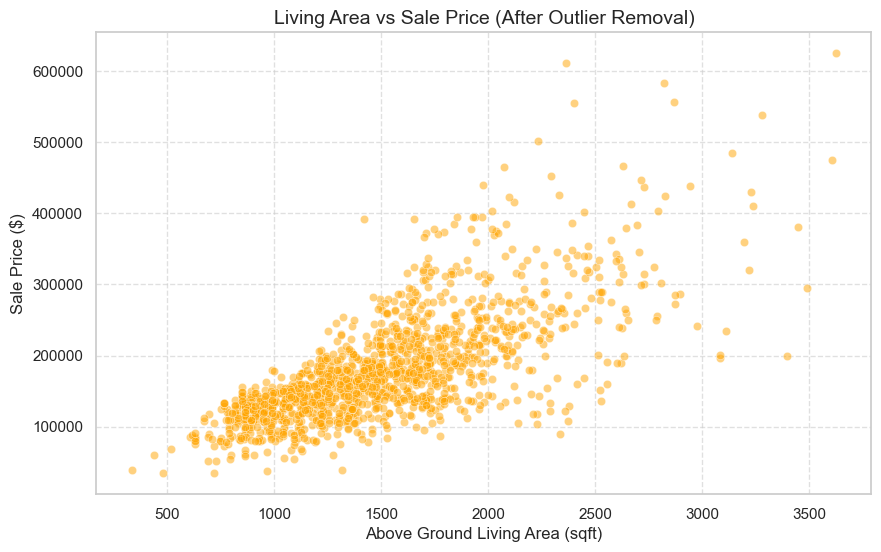

In [8]:
# Since in the scatter plot we can see that there are two outliers with a very large living area but a relatively low sale price.
# We will remove these outliers to improve the performace of our model.
df_cleaned = df_cleaned[df_cleaned['GrLivArea'] < 4000] # This line filters the dataset to include only rows with lower that 4000 sqft of living area.
print(f"✅ Outliers removed. New dataset shape: {df_cleaned.shape}") # This will show us the new shape of the dataset .

# Now lets visualize the scatter plot again after the removal of the outliers to see how it looks now and to confirm that the outliers have been removed successfully.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='GrLivArea', y='SalePrice', alpha=0.5, color='orange')
plt.title('Living Area vs Sale Price (After Outlier Removal)', fontsize=14)
plt.xlabel('Above Ground Living Area (sqft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Step 7

In [9]:
# Now for step 7, to evaluate the performance of our linear regression model, we must split our cleaned dataset into a training set and a testing set.
#This ensures that we can validate our model on "unseen" data and check for overfitting.
# We will use an 80-20 split, where 80% of the data is used for trainning and 20% is used for testing.
# We use the top_features list we created in Step 5 (excluding SalePrice).

from sklearn.model_selection import train_test_split # This line imports the train_test_split function from scikit-learn, which is used to split the dataset into training and testing sets.
X_features = [feature for feature in top_features if feature != 'SalePrice'] # This line creates a list of features to be used as the independent variables (x) for our regression model but it excludes 'SalesPrice' because that is our target variable (y) that we want to predict.
X = df_cleaned[X_features]
y = df_cleaned['SalePrice'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # This line splits the data into training and testing sets. 
# The test_size=0.2 means 20% for testing and the rest for training. The random_state=42 is used to ensure that the split is reproducible, so every time we run the code we get the same split of data which is important for consistent evaluation of our model's performance.
print(f" Automated Feature Selection: Using {len(X_features)} features.")
print(f"Features used: {X_features}")
print(f"✅ Data split complete! Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}") 
# Those lines will show us how many features we are using for the model and the number of samples in the training and testing sets. 

 Automated Feature Selection: Using 10 features.
Features used: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']
✅ Data split complete! Training samples: 1164, Testing samples: 292


Step 8

In [10]:
# Now for step 8,we will do the actual trainning of the model and the evaluation of its performance using the R-squared metric and the Mean Absolute Error.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score 

# Those lines import the LinearRegression model and the evaluation metrics from scikit-learn. 
# LinearRegression is the algorithm we will use to train our model,while the mean_absolute_error and r2_score are the metrics that will evaluate how well the model is performing in terms of accuracy and goodness of fit.
regressor = LinearRegression() # This line initializes the Linear Regression model.
regressor.fit(X_train, y_train) # This line trains the Linear Regression model using the training data (x_train and y-train).
y_pred = regressor.predict(X_test) # This line uses the trained model to make predictions on the testing set (x_test) and stores the predicted values in y_pred.
r2 = r2_score(y_test, y_pred)  # While this one calculates the R-squared value, which indicates how well the independent variables explain the variance in the target variable. A higher R-squared value (closer to 1) indicates a better fit of the model to the data.
mae = mean_absolute_error(y_test, y_pred) # This one calculates the Mean Absolute Error, which measures the average magnitude of the errors in a set of predictions, without considering their direction. 
# It gives us an idea of how far off our predictions are from the actual values on average.

print(f" Model training complete!")
print(f"📊 R-squared Score: {r2:.4f}")
print(f"💸 Mean Absolute Error: ${mae:,.2f}") # Those lines will display the evaluation metrics of our trained model.

 Model training complete!
📊 R-squared Score: 0.8191
💸 Mean Absolute Error: $23,122.67


Step 9

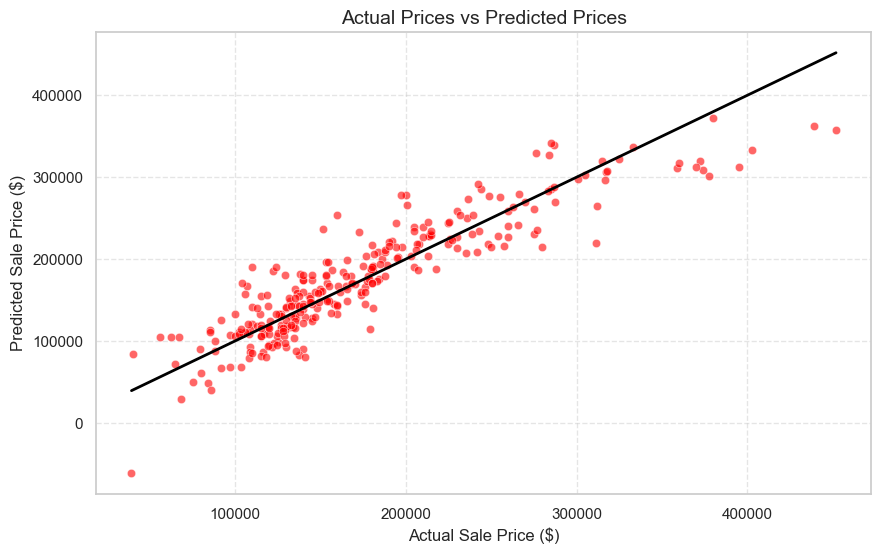

In [11]:
# Finally, for step 9, we will create a scatter plot to compare actual vs predicted values.
plt.figure(figsize=(10, 6)) # This sets the size of the plot.
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='red') # This line creates a scatter plot with the values of x and y being the predicted sale prices and the sale prices from the test. 
# The alpha parameter makes the points semi-transparent and the color is set to red since i like red. 

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'black', lw=2) # This line adds a dashed line to the plot that represents the ideal scenario where the predicted values perform perfectly against the actual values.
# The line is black (best combination of colors in my opinion) and has a width of 2 to make it more visible.

plt.title('Actual Prices vs Predicted Prices', fontsize=14) 
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # Those lines set the title and labels of the plot with a specific font size and a grid for better readability.
plt.show() # This line shows the plot.

We have now finished the first part of our analysis on predicting the exact sale price of houses. By using a Linear Regression model, we achieved a strong R-squared score of 0.8191. This means that our model can explain approximately 82% of the variance in house prices based on the selected features, which is a very solid result for this dataset.
The Mean Absolute Error  was calculated at $23,122.67, indicating the average difference between our predictions and the actual market prices. The visual inspection of the actual vs. predicted values also shows that our model is performing well and follows the general trend accurately. 
Especially after we removed the outliers, the predictions became much closer to the actual values, which confirms that our data cleaning and preprocessing steps were effective in significantly improving the model's performance.